In [3]:
from google.colab import drive
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mount the Drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/IPL_PROJECT/IPL_EDA_Base.csv'
df = pd.read_csv(file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df.columns

Index(['match_id', 'season', 'date', 'innings', 'batting_team', 'bowling_team',
       'over', 'ball', 'batter', 'bowler', 'runs_batter', 'runs_bowler',
       'runs_extras', 'runs_total', 'team_runs', 'wicket_kind', 'player_out',
       'venue', 'city', 'toss_winner', 'toss_decision', 'player_of_match',
       'winner', 'win_margin', 'is_four', 'is_six', 'is_boundary', 'is_dot',
       'is_single', 'is_wicket'],
      dtype='object')

In [5]:
df['wicket_kind'].value_counts()

,count
wicket_kind,
caught,8665
bowled,2345
run out,1153
lbw,853
caught and bowled,388
stumped,376
hit wicket,18
retired hurt,17
retired out,5


# **TOP WICKET TAKERS**

Question: Who has taken most number of wickets?

In [6]:
wickets=df[df['wicket_kind'].isin(['caught','bowled','lbw','caught and bowled','stumped','hit wicket'])]
top_bowlers = wickets.groupby('bowler').size().sort_values(ascending=False)
top_bowlers.name = 'wickets'
top_bowlers=top_bowlers.head(10)
top_bowlers

,wickets
bowler,
YS Chahal,221
B Kumar,198
PP Chawla,192
SP Narine,192
R Ashwin,187
JJ Bumrah,186
DJ Bravo,183
A Mishra,174
RA Jadeja,170


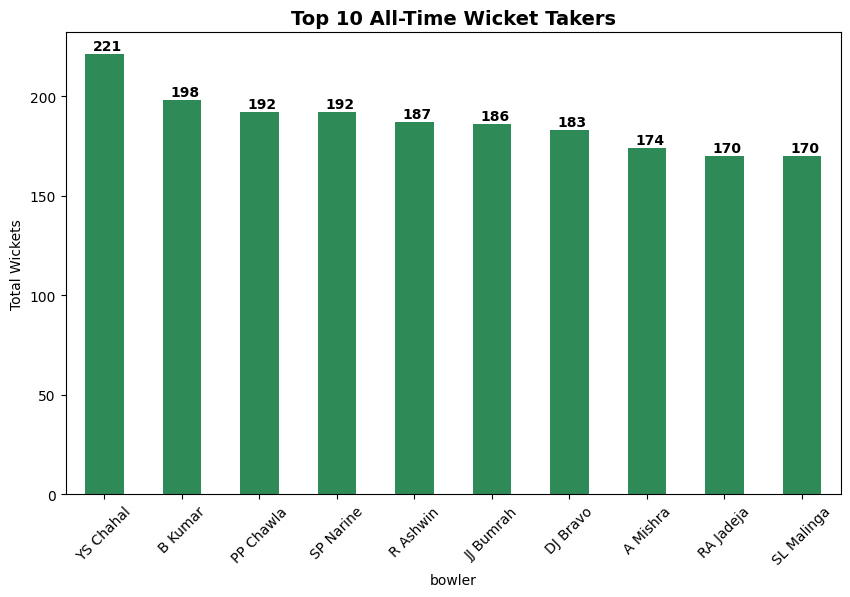

In [7]:
plt.figure(figsize=(10, 6))
ax = top_bowlers.plot(kind='bar', color='seagreen')
plt.title('Top 10 All-Time Wicket Takers', fontsize=14, fontweight='bold')
plt.ylabel('Total Wickets')
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + 0.1, p.get_height() + 2), fontweight='bold')

plt.show()

Insight:Top wicket-taking bowlers are often strike bowlers who are used in key phases of the match to break partnerships

# **Economy Rate**

Question: Which bowlers have the best economy rate(concedes least runs per over)?

In [8]:
df_legal = df[~((df['runs_batter'] == 0) & (df['runs_extras'] > 0))]
balls = df_legal.groupby('bowler').size()
runs = df.groupby('bowler')['runs_bowler'].sum()
bowling_stats = pd.DataFrame({
    'balls_bowled': balls,
    'runs_conceded': runs
})
bowling_stats['overs'] = bowling_stats['balls_bowled'] / 6
bowling_stats['overs_display'] = (
    (bowling_stats['balls_bowled'] // 6).astype(int).astype(str) + '.' +
    (bowling_stats['balls_bowled'] % 6).astype(int).astype(str)
)

bowling_stats['economy'] = (
    bowling_stats['runs_conceded'] / bowling_stats['overs']
)
bowling_stats['economy'] = bowling_stats['economy'].astype(float).round(1)
bowling_stats=bowling_stats[bowling_stats['balls_bowled']>=300]
bowling_stats.sort_values(by='economy', ascending=True).head(10)



,balls_bowled,runs_conceded,overs,overs_display,economy
bowler,,,,,
A Kumble,947,1058,157.833333,157.5,6.7
GD McGrath,316,357,52.666667,52.4,6.8
DL Vettori,764,879,127.333333,127.2,6.9
J Yadav,389,445,64.833333,64.5,6.9
M Muralitharan,1486,1706,247.666667,247.4,6.9
RE van der Merwe,432,498,72.000000,72.0,6.9
SP Narine,4287,4933,714.500000,714.3,6.9
J Botha,680,800,113.333333,113.2,7.1
DW Steyn,2142,2523,357.000000,357.0,7.1


Insight:Bowlers with low economy rates are effective at restricting runs, making them valuable in controlling the game’s tempo

# **Strike Rate (Bowling)**

Question: How frequently does a bowler take wickets?

In [9]:
wickets_count = wickets.groupby('bowler').size()

bowling_stats['wickets'] = wickets_count

bowling_stats = bowling_stats.fillna(0)

bowling_stats['bowling_strike_rate'] = (
    bowling_stats['balls_bowled'] / bowling_stats['wickets']
)
bowling_stats.sort_values(by='bowling_strike_rate').head(10)

,balls_bowled,runs_conceded,overs,overs_display,economy,wickets,bowling_strike_rate
bowler,,,,,,,
L Ngidi,366,529,61.000000,61.0,8.7,29,12.620690
R Sai Kishore,437,651,72.833333,72.5,8.9,32,13.656250
CR Woakes,429,658,71.500000,71.3,9.2,30,14.300000
M Pathirana,678,1016,113.000000,113.0,9.0,47,14.425532
AD Russell,1781,2863,296.833333,296.5,9.6,123,14.479675
A Zampa,463,652,77.166667,77.1,8.4,31,14.935484
MR Marsh,553,795,92.166667,92.1,8.6,37,14.945946
JR Hazlewood,854,1196,142.333333,142.2,8.4,57,14.982456
MF Maharoof,410,520,68.333333,68.2,7.6,27,15.185185


Insight:A lower bowling strike rate indicates a bowler’s ability to take wickets frequently

# **Dot ball percentage**

In [10]:
dot_balls = df_legal[df_legal['runs_batter'] == 0].groupby('bowler').size()

total_balls = df_legal.groupby('bowler').size()

bowling_dot = pd.DataFrame({
    'dot_balls': dot_balls,
    'total_balls': total_balls
}).fillna(0)

bowling_dot['dot_ball_%'] = (
    bowling_dot['dot_balls'] / bowling_dot['total_balls']
) * 100
bowling_stats['dot_ball_%'] = bowling_dot['dot_ball_%']
bowling_dot[bowling_dot['total_balls']>=300].sort_values(by='dot_ball_%', ascending=False).head(10)


,dot_balls,total_balls,dot_ball_%
bowler,,,
GD McGrath,153.0,316,48.417722
BW Hilfenhaus,173.0,363,47.658402
DW Steyn,1019.0,2142,47.572362
IC Pandey,212.0,452,46.902655
S Sreesanth,399.0,875,45.600000
DP Nannes,285.0,627,45.454545
DE Bollinger,254.0,562,45.195730
RJ Harris,364.0,807,45.105328
M Morkel,708.0,1603,44.167187


Insight: High dot ball percentages indicate bowlers who consistently build pressure, often leading to wickets

# **Bowling style analysis**

In [12]:
bowling_stats
# Calculate averages
avg_econ = bowling_stats['economy'].mean()
avg_sr = bowling_stats['bowling_strike_rate'].mean()
# Classify bowlers
def classify_bowler(row):
    if row['economy'] < avg_econ and row['bowling_strike_rate'] < avg_sr:
        return 'Elite'
    elif row['economy'] < avg_econ and row['bowling_strike_rate'] >= avg_sr:
        return 'Defensive'
    elif row['economy'] >= avg_econ and row['bowling_strike_rate'] < avg_sr:
        return 'Attacking'
    else:
        return 'Weak'

bowling_stats['bowling_type'] = bowling_stats.apply(classify_bowler, axis=1)
bowling_stats['bowling_type'].value_counts()

,count
bowling_type,
Attacking,62
Defensive,58
Elite,49
Weak,29


In [17]:
bowling_stats[bowling_stats['bowling_type'] == 'Elite'].head(10)

,balls_bowled,runs_conceded,overs,overs_display,economy,wickets,bowling_strike_rate,dot_ball_%,bowling_type
bowler,,,,,,,,,
A Kumble,947,1058,157.833333,157.5,6.7,45,21.044444,39.493136,Elite
A Mishra,3347,4145,557.833333,557.5,7.4,174,19.235632,35.404840,Elite
A Nehra,1884,2495,314.000000,314.0,7.9,106,17.773585,42.356688,Elite
A Singh,463,620,77.166667,77.1,8.0,28,16.535714,40.820734,Elite
A Zampa,463,652,77.166667,77.1,8.4,31,14.935484,30.021598,Elite
AD Mascarenhas,302,356,50.333333,50.2,7.1,19,15.894737,41.059603,Elite
Azhar Mahmood,532,700,88.666667,88.4,7.9,29,18.344828,37.406015,Elite
B Kumar,4125,5412,687.500000,687.3,7.9,198,20.833333,42.375758,Elite
BW Hilfenhaus,363,479,60.500000,60.3,7.9,22,16.500000,47.658402,Elite


In [19]:

bowling_stats[bowling_stats['bowling_type'] == 'Elite'].sort_values(by='economy').head(10)

,balls_bowled,runs_conceded,overs,overs_display,economy,wickets,bowling_strike_rate,dot_ball_%,bowling_type
bowler,,,,,,,,,
A Kumble,947,1058,157.833333,157.5,6.7,45,21.044444,39.493136,Elite
RE van der Merwe,432,498,72.000000,72.0,6.9,21,20.571429,34.259259,Elite
AD Mascarenhas,302,356,50.333333,50.2,7.1,19,15.894737,41.059603,Elite
Rashid Khan,3144,3781,524.000000,524.0,7.2,158,19.898734,36.513995,Elite
MM Ali,847,1029,141.166667,141.1,7.3,41,20.658537,34.828808,Elite
SL Malinga,2761,3366,460.166667,460.1,7.3,170,16.241176,41.434263,Elite
JJ Bumrah,3303,4059,550.500000,550.3,7.4,186,17.758065,40.962761,Elite
A Mishra,3347,4145,557.833333,557.5,7.4,174,19.235632,35.404840,Elite
SK Warne,1178,1447,196.333333,196.2,7.4,57,20.666667,36.162988,Elite


# Interpretation:

Type  	  |   Meaning

Elite     | 	Low economy + frequent wickets

Defensive | 	Controls runs but fewer wickets

Attacking	|  Takes wickets but leaks runs

Weak      | 	Poor in both

Insight: Bowlers can be categorized based on their ability to control runs and take wickets. Defensive bowlers maintain low economy rates but may lack wicket-taking frequency, while attacking bowlers prioritize breakthroughs at the cost of conceding more runs. Elite bowlers balance both aspects effectively.

# **Bowling scatter plot( Effectiveness)**

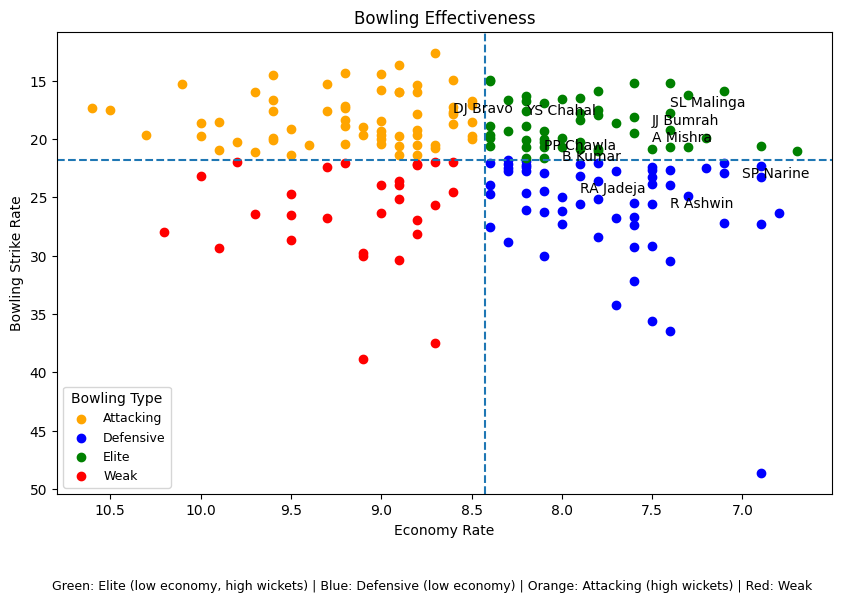

In [37]:
color_map = {
    'Elite': 'green',
    'Defensive': 'blue',
    'Attacking': 'orange',
    'Weak': 'red'
}

plt.figure(figsize=(10,6))

for btype, group in bowling_stats.groupby('bowling_type'):
    plt.scatter(
        group['economy'],
        group['bowling_strike_rate'],
        label=btype,
        color=color_map[btype]
    )

plt.xlabel('Economy Rate')
plt.ylabel('Bowling Strike Rate')
plt.title('Bowling Effectiveness')
avg_econ = bowling_stats['economy'].mean()
avg_sr = bowling_stats['bowling_strike_rate'].mean()

plt.axvline(avg_econ, linestyle='--')
plt.axhline(avg_sr, linestyle='--')
top_bowlers = bowling_stats.sort_values(by='wickets', ascending=False).head(10)

for bowler, row in top_bowlers.iterrows():
  plt.text(row['economy']+0.1, row['bowling_strike_rate']+1, bowler)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend(title='Bowling Type', loc='best', fontsize=9)
plt.figtext(
       0.5, -0.05,
    'Green: Elite (low economy, high wickets) | Blue: Defensive (low economy) | Orange: Attacking (high wickets) | Red: Weak',
    ha='center',
    fontsize=9
)
plt.show()




Insight: The scatter plot reveals distinct bowling roles, where elite bowlers combine low economy and frequent wicket-taking, while most bowlers specialize either in controlling runs or taking wickets. This highlights the inherent trade-off between economy and strike rate in T20 cricket

For example, bowlers like Yuzi chahal and Jasprit bumrah  fall into the elite category, while others clearly align with either defensive or attacking roles

# **Bowling Summary Table**

In [38]:
final_bowling = bowling_stats[[
    'runs_conceded',
    'balls_bowled',
    'economy',
    'wickets',
    'bowling_strike_rate',
    'dot_ball_%',
    'bowling_type'
]].copy()

final_bowling['effectiveness_score'] = (
    final_bowling['wickets'] / final_bowling['economy']
)
final_bowling['bowling_strike_rate'] = final_bowling['bowling_strike_rate'].round(1)
final_bowling['dot_ball_%'] = final_bowling['dot_ball_%'].round(1)
final_bowling = final_bowling.sort_values(
    by='effectiveness_score',
    ascending=False
)
final_bowling.head(10)

,runs_conceded,balls_bowled,economy,wickets,bowling_strike_rate,dot_ball_%,bowling_type,effectiveness_score
bowler,,,,,,,,
SP Narine,4933,4287,6.9,192,22.3,38.6,Defensive,27.826087
YS Chahal,5032,3742,8.1,221,16.9,33.8,Elite,27.283951
R Ashwin,5652,4656,7.3,187,24.9,34.5,Defensive,25.616438
JJ Bumrah,4059,3303,7.4,186,17.8,41.0,Elite,25.135135
B Kumar,5412,4125,7.9,198,20.8,42.4,Elite,25.063291
PP Chawla,5108,3818,8.0,192,19.9,34.7,Elite,24.000000
A Mishra,4145,3347,7.4,174,19.2,35.4,Elite,23.513514
SL Malinga,3366,2761,7.3,170,16.2,41.4,Elite,23.287671
Rashid Khan,3781,3144,7.2,158,19.9,36.5,Elite,21.944444


**Effectiveness score:**

The effectiveness score highlights bowlers who balance wicket-taking ability with economical bowling, emphasizing that impact in T20 cricket is driven by multi-dimensional performance rather than a single metric

# **Final bowling insights**

**Insight 1: Elite Bowlers**

Only a small group of bowlers achieve both low economy and low strike rate, highlighting their ability to control runs while consistently taking wickets.

**Insight 3: Role Specialization**

Most bowlers specialize either in defensive bowling (low economy) or attacking bowling (frequent wickets), reflecting distinct strategic roles in T20 cricket

#### **Insight 3: Dot Ball Impact**

Bowlers with higher dot ball percentages tend to maintain lower economy rates, indicating that building pressure through dot deliveries is a key factor in restricting runs.

**Insight 4: Effectiveness Score**

The effectiveness score shows that bowlers who balance wicket-taking ability with economical bowling provide the highest overall impact in matches

**Insight 5:** **Most Effective bowlers**

Bowlers with both high dot ball percentages and low strike rates tend to be the most effective, as they combine pressure-building with wicket-taking ability.

**Conclusion:**

The analysis reveals a clear trade-off between economy and strike rate, with only a few bowlers excelling in both. These elite performers are crucial in T20 cricket, as they contribute across multiple dimensions of the game